<a href="https://colab.research.google.com/github/Asfilcnx3/Project6_FashionMN/blob/main/FashionMNIST_Project6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Now we will use the FashionMNIST dataset to upgrade the arquitecture of the model

In [14]:
# Load all librarys
from torchvision import datasets, transforms
import torch
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from torch import nn, optim
import torch.nn.functional as F

# Use cuda to optimize
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Estas usando: {device}")

Estas usando: cuda


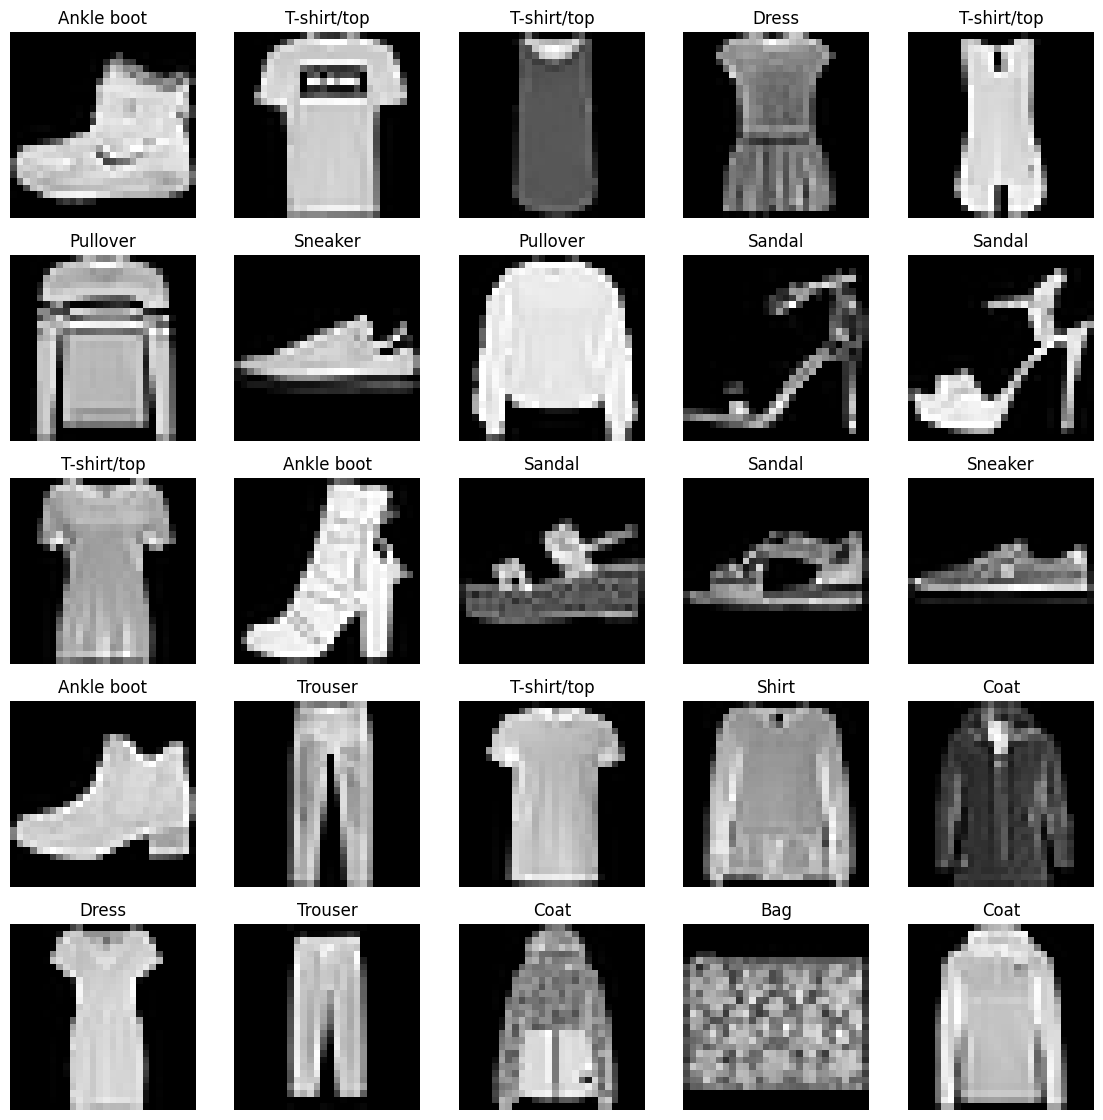

In [15]:
# Visualize data (optional)

# First, we need to load the data without any type of transformation
data = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())

df = pd.DataFrame(data.data.numpy().reshape(-1, 28*28))
y = data.targets.numpy()

label = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(14, 14))
for i in range(25):
  plt.subplot(5, 5, i+1)
  plt.imshow(df.iloc[i].values.reshape(28, 28), cmap="gray")
  plt.title(label[y[i]])
  plt.axis("off")

In [19]:
# Now, we'll make "Data Augmentation"
transform_train = transforms.Compose([
  transforms.RandomRotation(10),
  transforms.RandomAffine(0, translate=(0.1, 0.1)),
  transforms.ToTensor(),
  transforms.Normalize((0.5,), (0.5,))
]) # With Data Augmentation

transform_test = transforms.Compose([
  transforms.ToTensor(),
  transforms.Normalize((0.5,), (0.5,))
]) # Without Data Augmentation

full_train_data = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform_train)
full_test_data = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform_test) # Sin data Augmentation


# Manual Data Split
train_size = int(0.8 * len(full_train_data)) # 48,000
test_size = int(0.1 * len(full_train_data)) # 6,000
valid_size = int(0.1 * len(full_train_data)) # 6,000

train_data, _, _ = random_split(full_train_data, [train_size, test_size, valid_size]) # Data augmentation only in "train"

_, valid_data, test_data = random_split(full_test_data, [train_size, test_size, valid_size])

# Using a batchsize in the DataLoader
batch_size = 64

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size)
valid_loader = DataLoader(valid_data, batch_size=batch_size)

print(len(train_data))
print(len(valid_data))
print(len(test_data))

48000
6000
6000


### Creating a different CNN

* The arquitecture will be:

`Conv2D -> MaxPool -> Conv2D -> MaxPool -> Dropout -> Flatten -> Dense -> Dense`

Epoch: 1/50, Train Loss: 0.6484, Val Loss: 0.4139, Val Acc: 84.75%
----------------------------------------
Epoch: 2/50, Train Loss: 0.4475, Val Loss: 0.3360, Val Acc: 87.75%
----------------------------------------
Epoch: 3/50, Train Loss: 0.3985, Val Loss: 0.3115, Val Acc: 88.58%
----------------------------------------
Epoch: 4/50, Train Loss: 0.3610, Val Loss: 0.2912, Val Acc: 89.43%
----------------------------------------
Epoch: 5/50, Train Loss: 0.3391, Val Loss: 0.2820, Val Acc: 89.78%
----------------------------------------
Epoch: 6/50, Train Loss: 0.3237, Val Loss: 0.2641, Val Acc: 90.72%
----------------------------------------
Epoch: 7/50, Train Loss: 0.3099, Val Loss: 0.2522, Val Acc: 90.67%
----------------------------------------
Epoch: 8/50, Train Loss: 0.3002, Val Loss: 0.2291, Val Acc: 92.05%
----------------------------------------
Epoch: 9/50, Train Loss: 0.2906, Val Loss: 0.2335, Val Acc: 91.67%
----------------------------------------
Epoch: 10/50, Train Loss: 0.

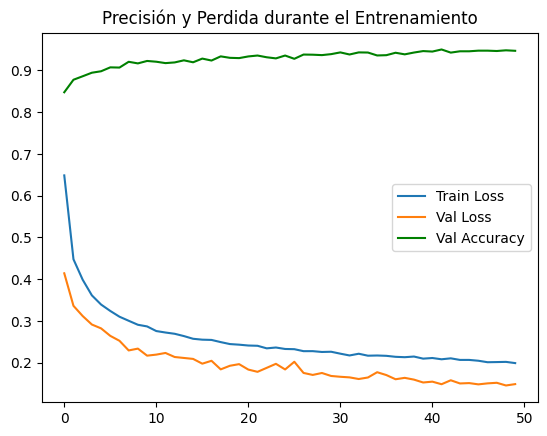

In [17]:
# Making a CNN
class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()

    self.conv1 = nn.Conv2d(1, 32, 3,padding=1)
    self.conv2 = nn.Conv2d(32, 64, 3,  padding=1)
    self.pool = nn.MaxPool2d(2, 2)
    self.dropout = nn.Dropout(0.25) # Add dropout
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(64* 7 * 7, 128)
    self.out = nn.Linear(128, 10)

  def forward(self, x):
    x = F.relu(self.conv1(x))
    x = self.pool(x)
    x = F.relu(self.conv2(x))
    x = self.pool(x)
    x = self.dropout(x)
    x = self.flatten(x)
    x = F.relu(self.fc1(x))
    return self.out(x)

# Working with cuda GPU
model = CNN().to(device)
# params
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.NAdam(model.parameters(), lr=0.001)


### Creating the training loop
### We'll agregate the "Early Stopping" to train +20 epochs without risk

epochs = 50
best_val_loss = float('inf')
patience = 5
counter = 0

train_losses = []
val_accs = []
val_losses = []

for epoch in range(epochs):
  model.train()
  running_loss = 0

  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = loss_fn(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()

  train_losses.append(running_loss / len(train_loader))

  # Evaluate with the valid sed
  model.eval()
  val_loss = 0
  all_preds = []
  all_labels = []

  with torch.no_grad():
    for images, labels in valid_loader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      loss = loss_fn(outputs, labels)
      val_loss += loss.item()
      _, predicted = torch.max(outputs, 1)
      all_preds.extend(predicted.cpu().numpy())
      all_labels.extend(labels.cpu().numpy())

  acc = accuracy_score(all_labels, all_preds)
  val_losses.append(val_loss / len(valid_loader))
  val_accs.append(acc)

  print(f"Epoch: {epoch+1}/{epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accs[-1]*100:.2f}%")
  print("----" * 10)

  if val_losses[-1] < best_val_loss:
    best_val_loss = val_losses[-1]
    counter = 0
    # Saving the model
    torch.save(model.state_dict(), "best_model.pt")
  else:
    counter += 1
    if counter >= patience:
      print(f"Early stopping on epoch {epoch + 1}")
      break

# Visualize the training
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.plot(val_accs, label="Val Accuracy", color='green')
plt.title("Loss and Accuracy on Training")
plt.legend()
plt.show()

Accuracy: 95.4833%
----------------------------------------


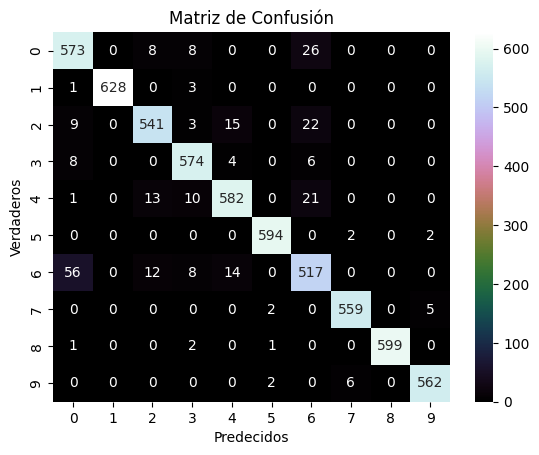

In [18]:
# Evaluate with the test set
all_preds = []
all_labels = []
model = CNN().to(device)
model.load_state_dict(torch.load("best_model.pt"))
model.eval()


with torch.no_grad():
  for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)
    all_preds.extend(predicted.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f'Accuracy: {acc*100:.4f}%')
print("----" * 10)

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap="cubehelix")
plt.xlabel("Predict")
plt.ylabel("True")
plt.title("Confussión Matrix")
plt.show()